# 🧠 ML-NLPEmot: Emotion Detection Pipeline
**Notebook version** — end-to-end emotion classification from social-media text.
Steps: Load → Clean → Preprocess → Feature-extract → Train & Evaluate → Visualise

## 1. Imports & Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys, os, logging

# Add src to path
sys.path.insert(
    0,
    str(Path(r"C:\Users\heman\ml-nlpemot\src") )
)


from preprocessing.text_normalizer import TextPreprocessor
from feature_extraction.feature_combiner import FeatureExtractor
from models.model_trainer import EmotionClassifierPipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ── Plotting style ──
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
PALETTE = sns.color_palette('viridis', 10)

print('✅ All imports successful')

✅ All imports successful


## 2. Configuration

In [4]:
# ── Edit this path to point to your CSV ──
DATA_PATH = r"C:\Users\heman\ml-nlpemot\src\data_collection\Combined_Data.csv"

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

TEST_SIZE   = 0.2
RANDOM_STATE = 42
MAX_FEATURES = 5000

print(f'📂 Data  : {DATA_PATH}')
print(f'📁 Output: {RESULTS_DIR.absolute()}')

📂 Data  : C:\Users\heman\ml-nlpemot\src\data_collection\Combined_Data.csv
📁 Output: c:\Users\heman\ml-nlpemot\src\results


## 3. Load & Inspect Data

In [5]:
df = pd.read_csv(DATA_PATH, encoding_errors='ignore')

print(f'Shape          : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'Missing values :\n{df.isnull().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')

# Per-column stats
col_stats = pd.DataFrame({
    'unique':  [df[c].nunique() for c in df.columns],
    'avg_len': [df[c].astype(str).str.len().mean().round(1) for c in df.columns],
    'sample':  [str(df[c].dropna().iloc[0])[:60] if df[c].dropna().shape[0] else 'EMPTY' for c in df.columns]
}, index=df.columns)

print('\n--- Column summary ---')
print(col_stats)

df.head()

Shape          : (44638, 2)
Columns        : ['statement', 'status']
Missing values :
statement    31425
status       31078
dtype: int64
Duplicates     : 32195

--- Column summary ---
           unique  avg_len      sample
statement   12435    673.1  oh my gosh
status          7      8.3     Anxiety


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


## 4. Auto-detect Text & Label Columns

In [6]:
def detect_columns(df):
    text_col = label_col = None
    for col in df.columns:
        avg_len    = df[col].astype(str).str.len().mean()
        uniq_ratio = df[col].nunique() / len(df)
        if avg_len > 20 and uniq_ratio > 0.05:
            if text_col is None or avg_len > df[text_col].astype(str).str.len().mean():
                text_col = col
        if avg_len < 30 and uniq_ratio < 0.05:
            if label_col is None or uniq_ratio < df[label_col].nunique() / len(df):
                label_col = col
    # Fallbacks
    if text_col  is None:
        for n in ['statement','text','tweet','message','content','post']:
            if n in df.columns: text_col = n; break
    if label_col is None:
        for n in ['status','label','emotion','sentiment','category']:
            if n in df.columns: label_col = n; break
    return text_col, label_col

TEXT_COL, LABEL_COL = detect_columns(df)
print(f'📝 Text  column : "{TEXT_COL}"')
print(f'🏷️  Label column : "{LABEL_COL}"')

📝 Text  column : "statement"
🏷️  Label column : "status"


## 5. Data Cleaning

In [7]:
initial = len(df)

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[TEXT_COL]  = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

df = df[df[TEXT_COL].str.strip().str.len() >= 3]        # remove very short text
df = df.drop_duplicates(subset=[TEXT_COL])               # remove duplicates

# Drop rare labels (< 5 samples)
counts      = df[LABEL_COL].value_counts()
rare_labels = counts[counts < 5].index.tolist()
if rare_labels:
    print(f'⚠️  Dropping rare labels: {rare_labels}')
    df = df[~df[LABEL_COL].isin(rare_labels)]

df = df.reset_index(drop=True)
print(f'Rows : {initial} → {len(df)}')
print(f'\nLabel distribution:\n{df[LABEL_COL].value_counts()}')

Rows : 44638 → 12434

Label distribution:
status
Bipolar                 2501
Stress                  2295
Normal                  2224
Depression              2046
Anxiety                 1445
Suicidal                1028
Personality disorder     895
Name: count, dtype: int64


### Label Distribution Plot

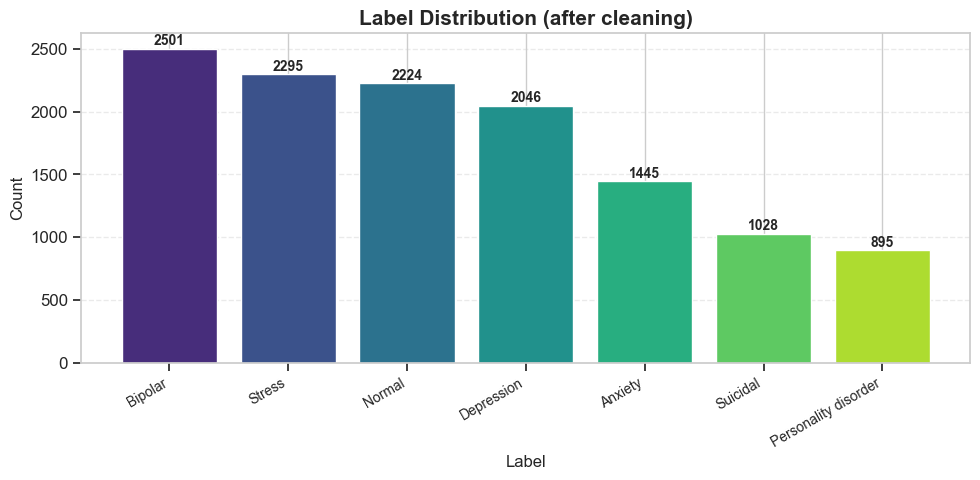

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
val_counts = df[LABEL_COL].value_counts()
bars = ax.bar(val_counts.index, val_counts.values, color=sns.color_palette('viridis', len(val_counts)), edgecolor='white')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 8, str(int(h)),
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Label Distribution (after cleaning)', fontsize=15, fontweight='bold')
ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 6. Text Preprocessing

In [9]:
preprocessor = TextPreprocessor(language='english')

try:
    df['clean_text'] = preprocessor.preprocess_batch(df[TEXT_COL], return_string=True, show_progress=True)
except Exception as e:
    print(f'⚠️  Preprocessor error: {e}  →  falling back to lower-strip')
    df['clean_text'] = df[TEXT_COL].str.lower().str.strip()

# Drop empty results
before = len(df)
df = df[df['clean_text'].str.strip().str.len() >= 1]
print(f'Removed {before - len(df)} empty-after-preprocessing rows')

# Show samples
sample = df[[TEXT_COL, 'clean_text']].head(5).copy()
sample.columns = ['Original', 'Preprocessed']
sample

2026-02-03 11:02:21,558 - INFO - TextPreprocessor initialized with 198 stopwords
2026-02-03 11:02:28,110 - INFO - Processed 100/12434 texts
2026-02-03 11:02:28,157 - INFO - Processed 200/12434 texts
2026-02-03 11:02:28,204 - INFO - Processed 300/12434 texts
2026-02-03 11:02:28,241 - INFO - Processed 400/12434 texts
2026-02-03 11:02:28,280 - INFO - Processed 500/12434 texts
2026-02-03 11:02:28,316 - INFO - Processed 600/12434 texts
2026-02-03 11:02:28,347 - INFO - Processed 700/12434 texts
2026-02-03 11:02:28,382 - INFO - Processed 800/12434 texts
2026-02-03 11:02:28,412 - INFO - Processed 900/12434 texts
2026-02-03 11:02:28,437 - INFO - Processed 1000/12434 texts
2026-02-03 11:02:28,465 - INFO - Processed 1100/12434 texts
2026-02-03 11:02:28,500 - INFO - Processed 1200/12434 texts
2026-02-03 11:02:28,535 - INFO - Processed 1300/12434 texts
2026-02-03 11:02:28,566 - INFO - Processed 1400/12434 texts
2026-02-03 11:02:28,597 - INFO - Processed 1500/12434 texts
2026-02-03 11:02:28,622 - IN

Removed 9 empty-after-preprocessing rows


,Original,Preprocessed
0,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean


## 7. Feature Extraction & Train / Test Split

In [10]:
label_names      = sorted(df[LABEL_COL].unique().tolist())
min_samples      = df[LABEL_COL].value_counts().min()
stratify_col     = df[LABEL_COL] if min_samples >= 2 else None

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['clean_text'], df[LABEL_COL],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify_col
)

print(f'Train : {len(X_train_txt)}   Test : {len(X_test_txt)}')
print(f'Labels: {label_names}')

max_feat = min(MAX_FEATURES, len(X_train_txt))
extractor = FeatureExtractor(max_features=max_feat, min_df=2, max_df=0.95, ngram_range=(1,2))

X_train = extractor.fit_transform_concatenated(X_train_txt)
X_test  = extractor.transform_concatenated(X_test_txt)

print(f'Feature matrix  → Train {X_train.shape}   Test {X_test.shape}')
print(f'Density         → {X_train.nnz / (X_train.shape[0]*X_train.shape[1]):.4f}')

2026-02-03 11:02:52,768 - INFO - FeatureExtractor initialized
2026-02-03 11:02:52,771 - INFO - Fitting all vectorizers...
2026-02-03 11:02:52,772 - INFO - Fitting Bag of Words vectorizer...


Train : 9940   Test : 2485
Labels: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


2026-02-03 11:02:58,697 - INFO - BoW vocabulary size: 5000
2026-02-03 11:02:58,699 - INFO - Fitting TF-IDF vectorizer...
2026-02-03 11:03:03,811 - INFO - TF-IDF vocabulary size: 5000
2026-02-03 11:03:03,813 - INFO - All vectorizers fitted successfully
2026-02-03 11:03:03,814 - INFO - Extracting concatenated BoW + TF-IDF features...
2026-02-03 11:03:06,176 - INFO - BoW features shape: (9940, 5000)
2026-02-03 11:03:08,332 - INFO - TF-IDF features shape: (9940, 5000)
2026-02-03 11:03:08,349 - INFO - Concatenated features shape: (9940, 10000)
2026-02-03 11:03:08,351 - INFO -   BoW features: 5000
2026-02-03 11:03:08,353 - INFO -   TF-IDF features: 5000
2026-02-03 11:03:08,354 - INFO -   Total features: 10000
2026-02-03 11:03:08,356 - INFO - Extracting concatenated BoW + TF-IDF features...
2026-02-03 11:03:08,901 - INFO - BoW features shape: (2485, 5000)
2026-02-03 11:03:09,540 - INFO - TF-IDF features shape: (2485, 5000)
2026-02-03 11:03:09,546 - INFO - Concatenated features shape: (2485, 1

Feature matrix  → Train (9940, 10000)   Test (2485, 10000)
Density         → 0.0098


## 8. Model Training & Cross-Validation

In [11]:
pipeline = EmotionClassifierPipeline(random_state=RANDOM_STATE)
MODELS   = ['random_forest', 'logistic_regression', 'svm', 'naive_bayes']

pipeline.train_all_models(X_train, y_train, models=MODELS)

n_folds = max(2, min(10, pd.Series(y_train).value_counts().min()))
print(f'\n📊 Running {n_folds}-fold cross-validation …')
try:
    pipeline.cross_validate_all(X_train, y_train, cv=n_folds)
except Exception as e:
    print(f'⚠️  CV failed: {e}')

print('✅ Training complete')

2026-02-03 11:03:09,575 - INFO - EmotionClassifierPipeline initialized (scikit-learn 1.8.0)
2026-02-03 11:03:09,578 - INFO - ================================================================================
2026-02-03 11:03:09,580 - INFO - TRAINING ALL MODELS
2026-02-03 11:03:09,582 - INFO - ================================================================================
2026-02-03 11:03:09,583 - INFO - 
Training Random Forest...
2026-02-03 11:03:34,007 - INFO - Training completed in 24.22 seconds
2026-02-03 11:03:34,010 - INFO - CPU: 0.00%
2026-02-03 11:03:34,011 - INFO - Memory: 315.54 MB
2026-02-03 11:03:34,012 - INFO - 
Training Logistic Regression...
2026-02-03 11:03:41,944 - INFO - Training completed in 7.73 seconds
2026-02-03 11:03:41,946 - INFO - CPU: 0.00%
2026-02-03 11:03:41,947 - INFO - Memory: 3.00 MB
2026-02-03 11:03:41,949 - INFO - 
Training Svm...
2026-02-03 11:12:36,304 - INFO - Training completed in 534.15 seconds
2026-02-03 11:12:36,305 - INFO - CPU: 0.00%
2026-02-03 1


📊 Running 10-fold cross-validation …


2026-02-03 11:14:58,533 - INFO - CV completed in 72.56 seconds
2026-02-03 11:14:58,534 - INFO - Accuracy: 0.7178 (±0.0120)
2026-02-03 11:14:58,535 - INFO - Precision: 0.7304 (±0.0159)
2026-02-03 11:14:58,536 - INFO - Recall: 0.7178 (±0.0120)
2026-02-03 11:14:58,537 - INFO - F1-Score: 0.6922 (±0.0119)
2026-02-03 11:14:58,537 - INFO - 
Cross-validating Logistic Regression...
2026-02-03 11:15:09,282 - INFO - CV completed in 5.37 seconds
2026-02-03 11:15:09,283 - INFO - Accuracy: 0.7327 (±0.0162)
2026-02-03 11:15:09,284 - INFO - Precision: 0.7309 (±0.0174)
2026-02-03 11:15:09,285 - INFO - Recall: 0.7327 (±0.0162)
2026-02-03 11:15:09,285 - INFO - F1-Score: 0.7302 (±0.0168)
2026-02-03 11:15:09,286 - INFO - 
Cross-validating Svm...
2026-02-03 11:28:47,588 - INFO - CV completed in 444.54 seconds
2026-02-03 11:28:47,589 - INFO - Accuracy: 0.7033 (±0.0103)
2026-02-03 11:28:47,589 - INFO - Precision: 0.7067 (±0.0139)
2026-02-03 11:28:47,590 - INFO - Recall: 0.7033 (±0.0103)
2026-02-03 11:28:47,59

✅ Training complete


## 9. Test-Set Evaluation & Predictions

In [12]:
pipeline.evaluate_all_models(X_test, y_test, label_names=label_names)

# ── collect per-model predictions for plotting ──
model_preds = {}   # { model_name : np.array of predicted labels }
for name in MODELS:
    try:
        model_preds[name] = pipeline.models[name].predict(X_test)
    except Exception:
        pass                # skip if model key differs

# ── comparison table ──
try:
    comparison_df = pipeline.get_comparison_table()
    print('\n--- Model Comparison ---')
    comparison_df
except Exception as e:
    print(f'⚠️  Comparison table: {e}')
    comparison_df = None

2026-02-03 11:28:48,253 - INFO - 
2026-02-03 11:28:48,254 - INFO - EVALUATING ALL MODELS ON TEST SET
2026-02-03 11:28:48,255 - INFO - ================================================================================
2026-02-03 11:28:48,255 - INFO - 
Evaluating Random Forest...
2026-02-03 11:28:48,582 - INFO - Accuracy: 0.7143
2026-02-03 11:28:48,583 - INFO - Precision: 0.7244
2026-02-03 11:28:48,584 - INFO - Recall: 0.7143
2026-02-03 11:28:48,584 - INFO - F1-Score: 0.6906
2026-02-03 11:28:48,585 - INFO - AUC: 0.9433
2026-02-03 11:28:48,585 - INFO - 
Evaluating Logistic Regression...
2026-02-03 11:28:48,663 - INFO - Accuracy: 0.7380
2026-02-03 11:28:48,664 - INFO - Precision: 0.7370
2026-02-03 11:28:48,665 - INFO - Recall: 0.7380
2026-02-03 11:28:48,665 - INFO - F1-Score: 0.7363
2026-02-03 11:28:48,666 - INFO - AUC: 0.9376
2026-02-03 11:28:48,666 - INFO - 
Evaluating Svm...
2026-02-03 11:29:16,669 - INFO - Accuracy: 0.7143
2026-02-03 11:29:16,670 - INFO - Precision: 0.7224
2026-02-03 11:


--- Model Comparison ---


## 10. Confusion Matrices — All Models

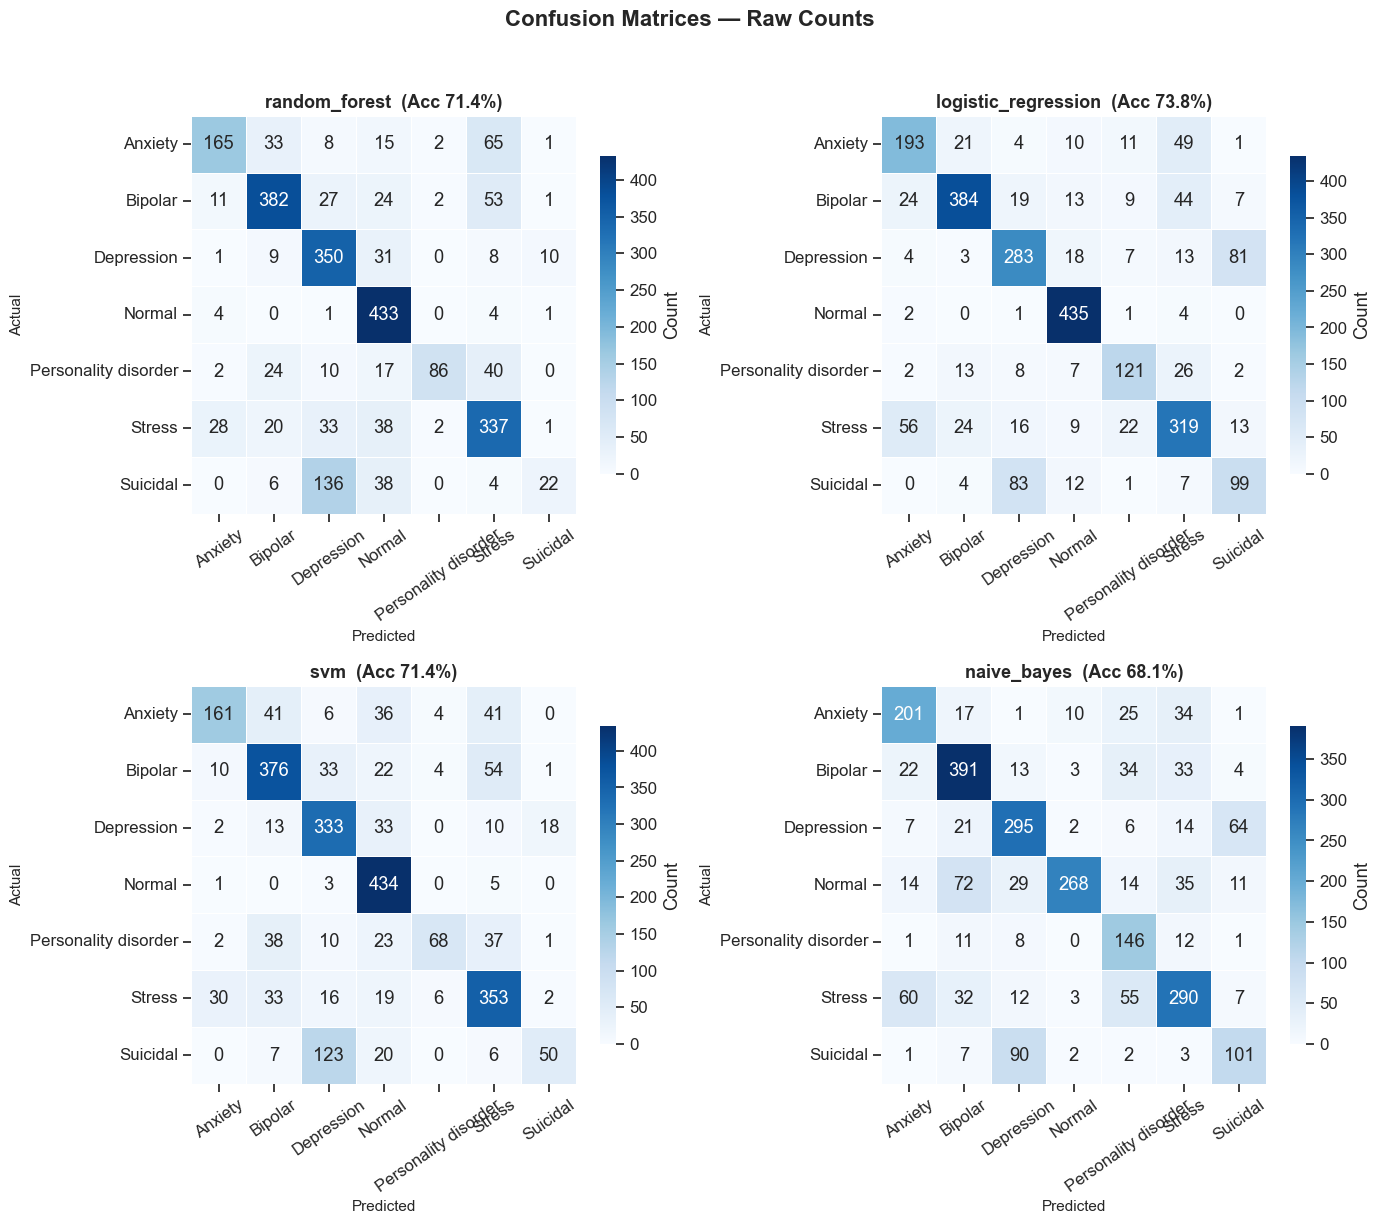

✅ Saved confusion_matrices_raw.png


In [13]:
n_models = len(model_preds)
if n_models == 0:
    print('⚠️  No predictions available – skipping.')
else:
    cols = min(2, n_models)
    rows = (n_models + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*6))
    axes = np.array(axes).reshape(-1)         # flatten even if 1-row

    for idx, (mname, preds) in enumerate(model_preds.items()):
        ax   = axes[idx]
        cm   = confusion_matrix(y_test, preds, labels=label_names)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=label_names, yticklabels=label_names,
                    linewidths=0.5, linecolor='white',
                    cbar_kws={'shrink':0.8, 'label':'Count'}, ax=ax)

        acc = accuracy_score(y_test, preds)
        ax.set_title(f'{mname}  (Acc {acc*100:.1f}%)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('Actual',    fontsize=11)
        ax.tick_params(axis='x', rotation=35)

    # Hide unused axes
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Confusion Matrices — Raw Counts', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'confusion_matrices_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved confusion_matrices_raw.png')

## 11. Normalised Confusion Matrices (Row-wise %)

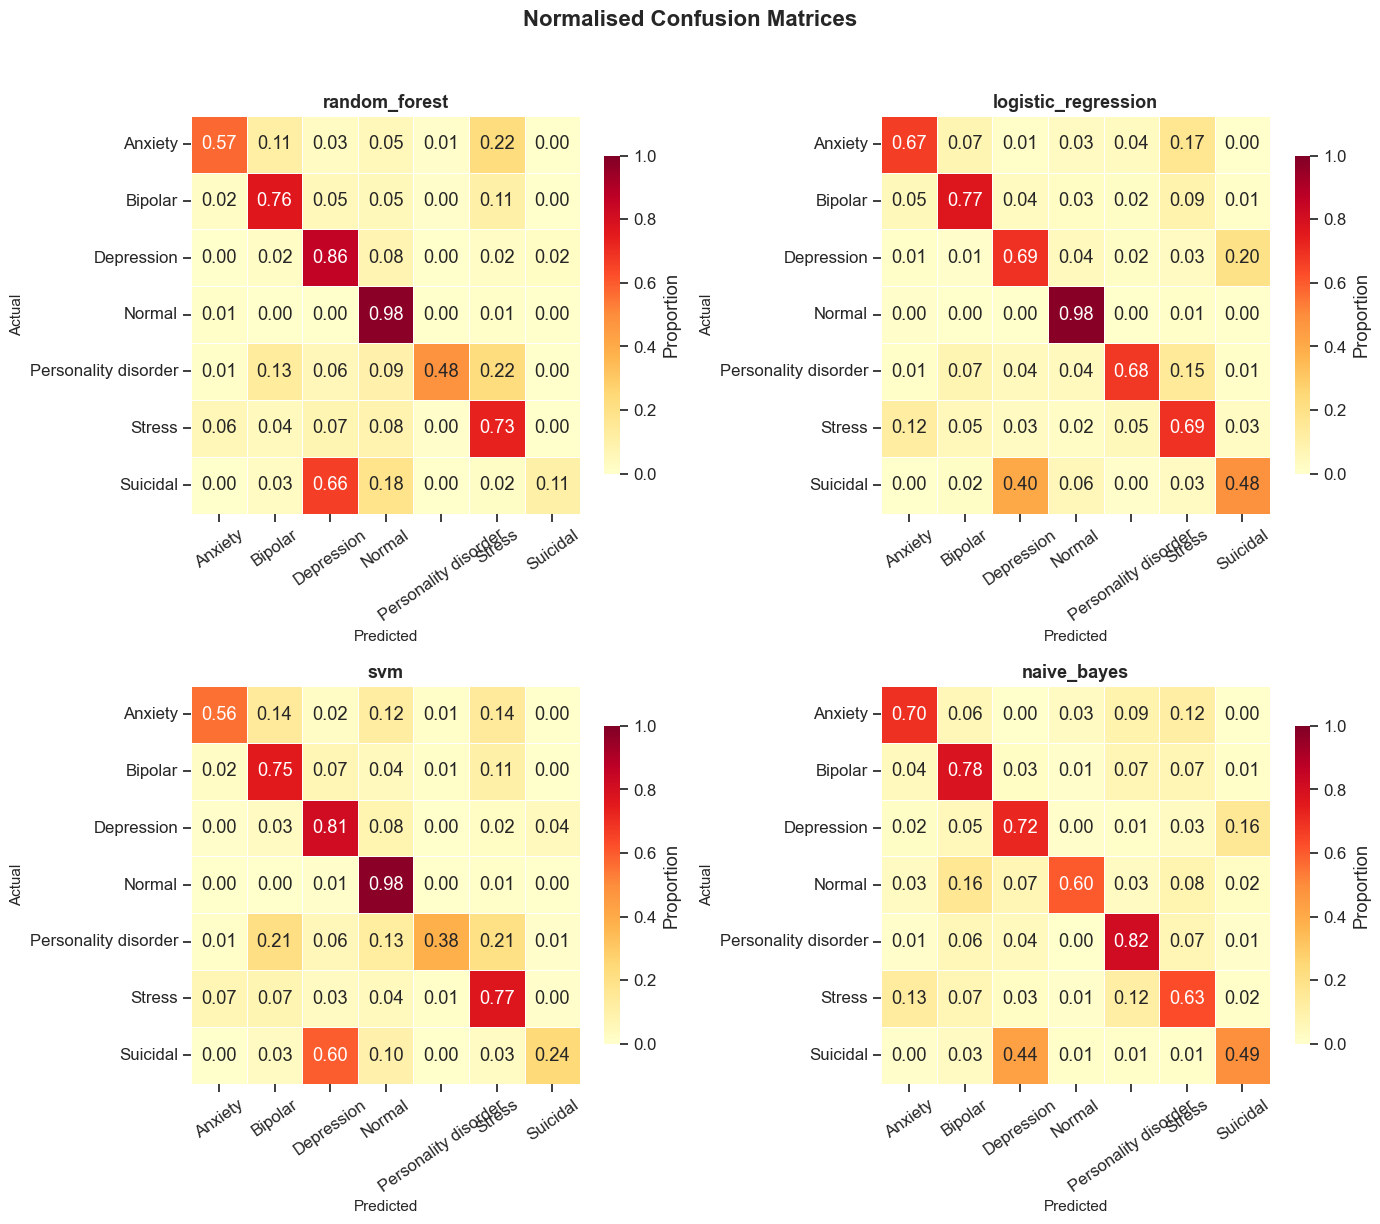

✅ Saved confusion_matrices_norm.png


In [14]:
if n_models == 0:
    print('⚠️  No predictions – skipping.')
else:
    fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*6))
    axes = np.array(axes).reshape(-1)

    for idx, (mname, preds) in enumerate(model_preds.items()):
        ax   = axes[idx]
        cm   = confusion_matrix(y_test, preds, labels=label_names)
        cm_n = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row normalise

        sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='YlOrRd',
                    xticklabels=label_names, yticklabels=label_names,
                    linewidths=0.5, linecolor='white', vmin=0, vmax=1,
                    cbar_kws={'shrink':0.8, 'label':'Proportion'}, ax=ax)

        ax.set_title(f'{mname}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('Actual',    fontsize=11)
        ax.tick_params(axis='x', rotation=35)

    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Normalised Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'confusion_matrices_norm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved confusion_matrices_norm.png')

## 12. Per-Class Performance Metrics — All Models

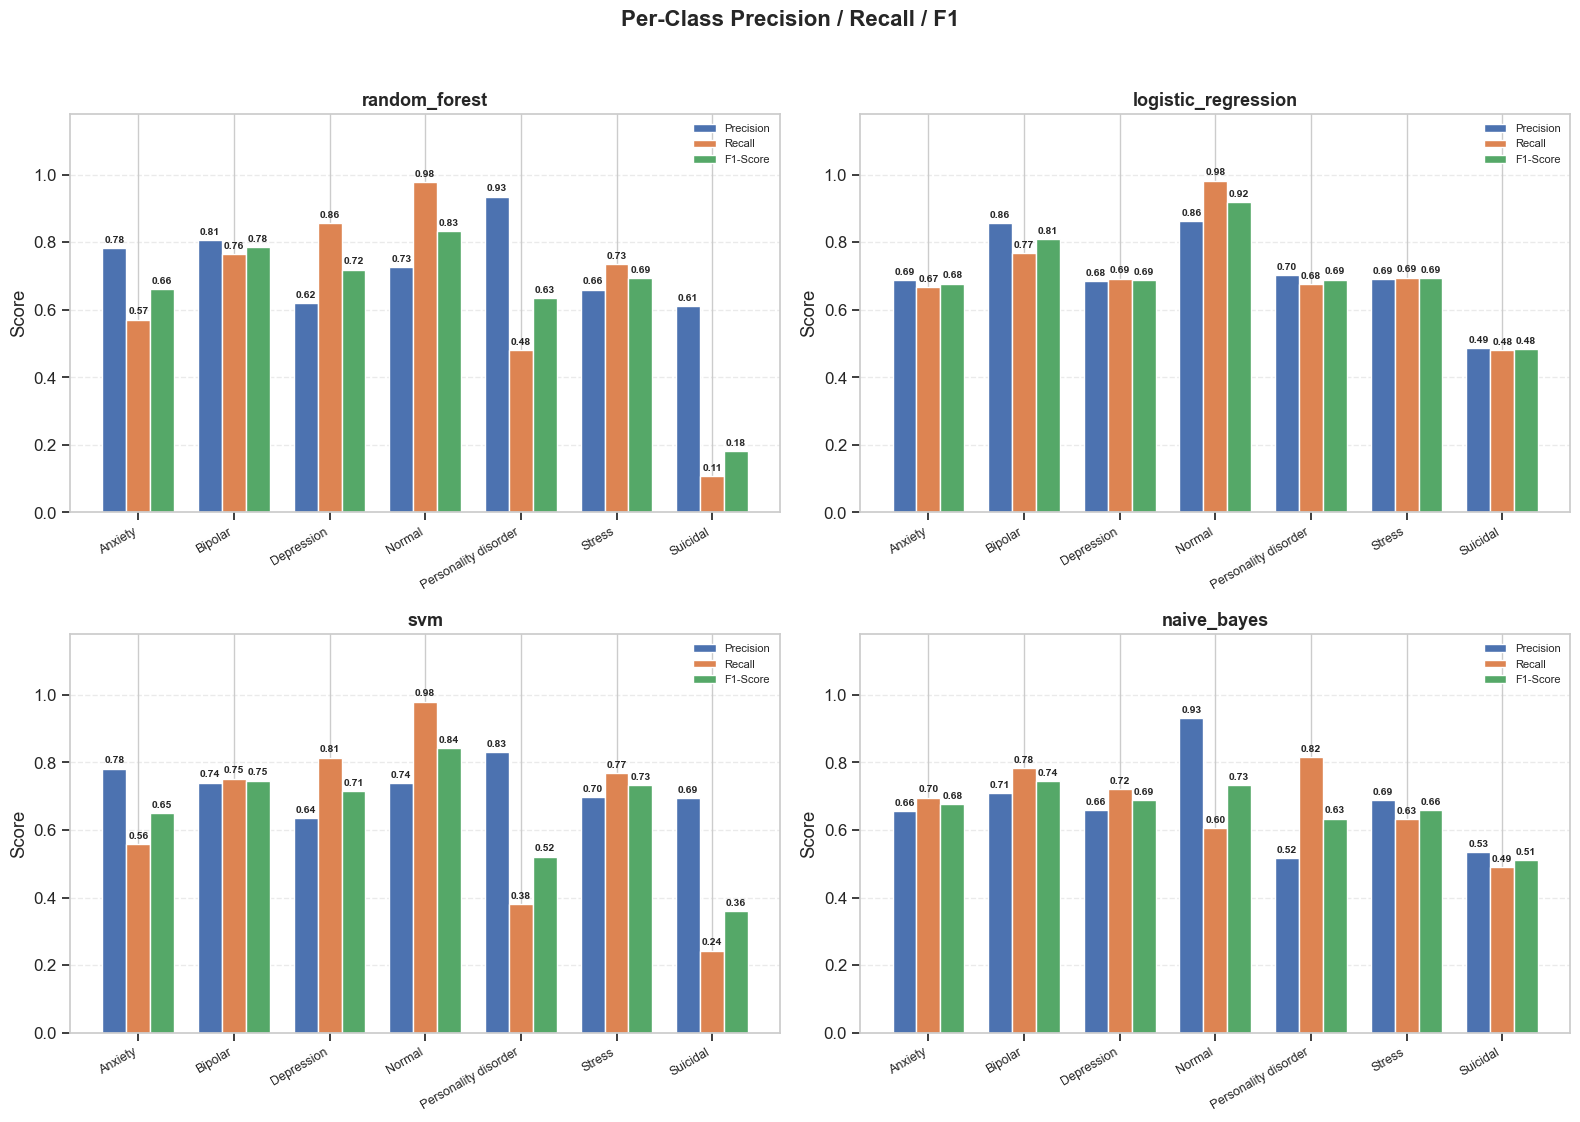

✅ Saved per_class_metrics.png


In [15]:
if n_models == 0:
    print('⚠️  No predictions – skipping.')
else:
    fig, axes = plt.subplots(rows, cols, figsize=(cols*8, rows*5.5))
    axes = np.array(axes).reshape(-1)

    for idx, (mname, preds) in enumerate(model_preds.items()):
        ax = axes[idx]
        rep = classification_report(y_test, preds, target_names=label_names, output_dict=True)

        prec = [rep[c]['precision'] for c in label_names]
        rec  = [rep[c]['recall']    for c in label_names]
        f1   = [rep[c]['f1-score']  for c in label_names]

        x = np.arange(len(label_names))
        w = 0.25

        b_p = ax.bar(x - w, prec, w, label='Precision', color='#4C72B0', edgecolor='white')
        b_r = ax.bar(x,     rec,  w, label='Recall',    color='#DD8452', edgecolor='white')
        b_f = ax.bar(x + w, f1,   w, label='F1-Score',  color='#55A868', edgecolor='white')

        for bars in [b_p, b_r, b_f]:
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}',
                        ha='center', va='bottom', fontsize=7.5, fontweight='bold')

        ax.set_title(f'{mname}', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(label_names, rotation=30, ha='right', fontsize=9)
        ax.set_ylim(0, 1.18)
        ax.set_ylabel('Score')
        ax.legend(fontsize=8, loc='upper right')
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)
        ax.set_axisbelow(True)

    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Per-Class Precision / Recall / F1', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved per_class_metrics.png')

## 13. Macro & Weighted Average Metrics — Model Comparison

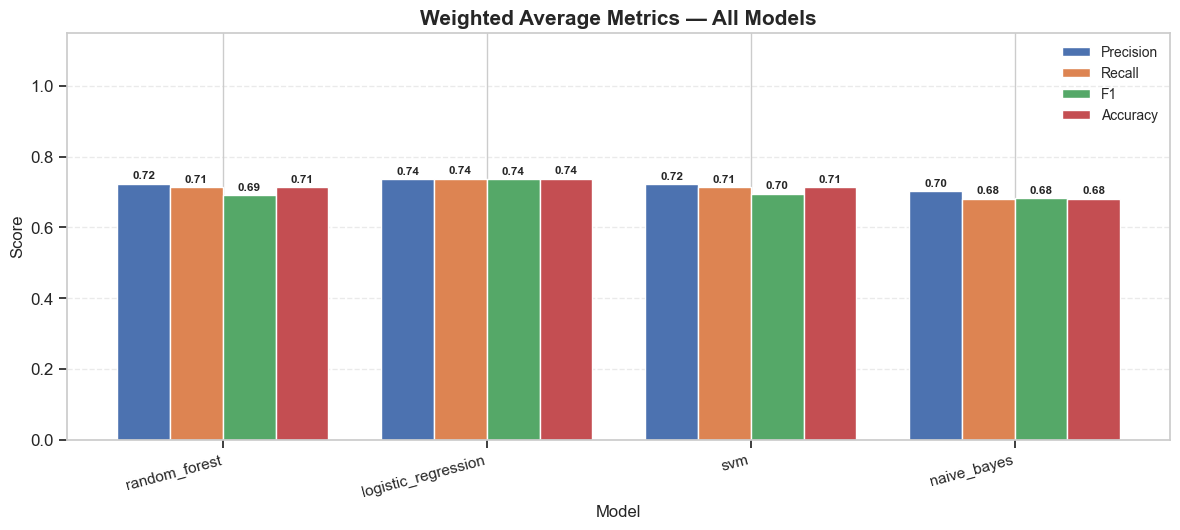

✅ Saved avg_metrics_comparison.png

--- Weighted Metrics Table ---


In [16]:
if n_models == 0:
    print('⚠️  No predictions – skipping.')
else:
    avg_data = {'Model':[], 'Precision':[], 'Recall':[], 'F1':[], 'Accuracy':[]}
    for mname, preds in model_preds.items():
        avg_data['Model'].append(mname)
        avg_data['Precision'].append(precision_score(y_test, preds, average='weighted', zero_division=0))
        avg_data['Recall'].append(recall_score(y_test, preds, average='weighted', zero_division=0))
        avg_data['F1'].append(f1_score(y_test, preds, average='weighted', zero_division=0))
        avg_data['Accuracy'].append(accuracy_score(y_test, preds))

    avg_df = pd.DataFrame(avg_data)

    x = np.arange(len(avg_df))
    w = 0.2

    fig, ax = plt.subplots(figsize=(12, 5.5))

    colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
    metrics = ['Precision','Recall','F1','Accuracy']
    for i, (metric, col) in enumerate(zip(metrics, colors)):
        bars = ax.bar(x + (i - 1.5)*w, avg_df[metric], w, label=metric, color=col, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_title('Weighted Average Metrics — All Models', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(avg_df['Model'], fontsize=11, rotation=15, ha='right')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'avg_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved avg_metrics_comparison.png')

    print('\n--- Weighted Metrics Table ---')
    avg_df.set_index('Model').round(4)

## 14. Full Classification Reports

In [17]:
for mname, preds in model_preds.items():
    print('='*65)
    print(f'  {mname.upper()}')
    print('='*65)
    print(classification_report(y_test, preds, target_names=label_names))


  RANDOM_FOREST
                      precision    recall  f1-score   support

             Anxiety       0.78      0.57      0.66       289
             Bipolar       0.81      0.76      0.78       500
          Depression       0.62      0.86      0.72       409
              Normal       0.73      0.98      0.83       443
Personality disorder       0.93      0.48      0.63       179
              Stress       0.66      0.73      0.69       459
            Suicidal       0.61      0.11      0.18       206

            accuracy                           0.71      2485
           macro avg       0.73      0.64      0.64      2485
        weighted avg       0.72      0.71      0.69      2485

  LOGISTIC_REGRESSION
                      precision    recall  f1-score   support

             Anxiety       0.69      0.67      0.68       289
             Bipolar       0.86      0.77      0.81       500
          Depression       0.68      0.69      0.69       409
              Normal       0

## 15. Save Models & Reports

In [18]:
# Save comparison CSV
if comparison_df is not None:
    comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
    print('✅ model_comparison.csv')

# Save trained models
try:
    pipeline.save_all_models(directory=str(RESULTS_DIR / 'models'))
    print('✅ models/')
except Exception as e:
    print(f'⚠️  {e}')

# Save text report
try:
    pipeline.generate_full_report(save_path=str(RESULTS_DIR / 'model_report.txt'))
    print('✅ model_report.txt')
except Exception as e:
    print(f'⚠️  {e}')

print(f'\n📁 All outputs in → {RESULTS_DIR.absolute()}')

✅ model_comparison.csv


2026-02-03 11:29:36,854 - INFO - Model random_forest saved to results\models\random_forest_model.pkl
2026-02-03 11:29:36,857 - INFO - Model logistic_regression saved to results\models\logistic_regression_model.pkl
2026-02-03 11:29:36,864 - INFO - Model svm saved to results\models\svm_model.pkl
2026-02-03 11:29:36,867 - INFO - Model naive_bayes saved to results\models\naive_bayes_model.pkl


✅ models/


2026-02-03 11:29:36,872 - INFO - Full report saved to results\model_report.txt


✅ model_report.txt

📁 All outputs in → c:\Users\heman\ml-nlpemot\src\results
